# Task 4: Predicting Insurance Claim Amounts

## Introduction & Problem Statement
Medical insurance companies need to estimate the **claim amount** a customer might incur based on personal attributes. Accurate prediction helps set appropriate premium levels and manage risk.

### Objective:
Train a **Linear Regression** model (and compare with Ridge/Random Forest) to predict medical insurance charges based on features like age, BMI, smoking status, and region.

### Dataset:
**Medical Cost Personal Dataset** — 1,338 records with features: age, sex, BMI, children, smoker, region, charges.

In [1]:
# ── Install & import libraries ───────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

print('Libraries loaded!')

Libraries loaded!


## 1. Dataset Understanding & Description



In [2]:
from google.colab import files
uploaded = files.upload()  # insurance.csv upload karo
df = pd.read_csv('insurance.csv')

print(f'Dataset shape: {df.shape}')
df.head()

Saving insurance.csv to insurance.csv
Dataset shape: (1338, 7)


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [3]:
# ── Basic stats ──────────────────────────────────────────────────────────────
print('=== Dataset Info ===')
df.info()
print('\n=== Missing Values ===')
print(df.isnull().sum())
print('\n=== Statistical Summary ===')
df.describe()

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB

=== Missing Values ===
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

=== Statistical Summary ===


,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


## 2. Exploratory Data Analysis (EDA)

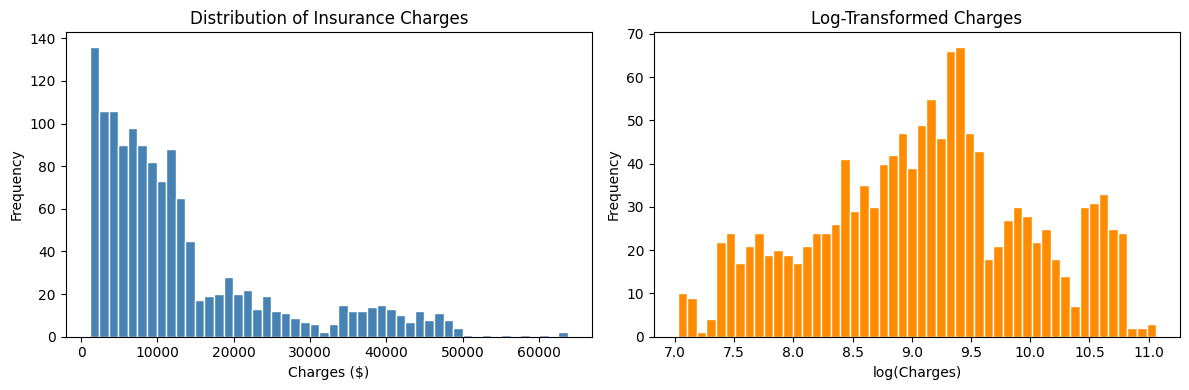

Insight: Charges are right-skewed. Log transformation makes it more normal.


In [4]:
# ── Charges distribution ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['charges'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of Insurance Charges')
axes[0].set_xlabel('Charges ($)')
axes[0].set_ylabel('Frequency')

axes[1].hist(np.log1p(df['charges']), bins=50, color='darkorange', edgecolor='white')
axes[1].set_title('Log-Transformed Charges')
axes[1].set_xlabel('log(Charges)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()
print('Insight: Charges are right-skewed. Log transformation makes it more normal.')

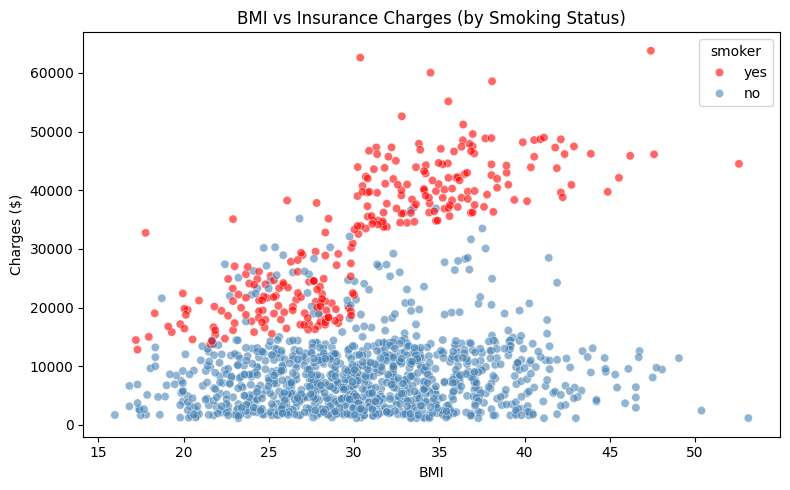

Insight: Smokers with high BMI incur dramatically higher charges — two compounding risk factors.


In [5]:
# ── BMI vs Charges (colored by Smoker) ───────────────────────────────────────
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='bmi', y='charges', hue='smoker',
                palette={'yes': 'red', 'no': 'steelblue'}, alpha=0.6)
plt.title('BMI vs Insurance Charges (by Smoking Status)')
plt.xlabel('BMI')
plt.ylabel('Charges ($)')
plt.tight_layout()
plt.show()
print('Insight: Smokers with high BMI incur dramatically higher charges — two compounding risk factors.')

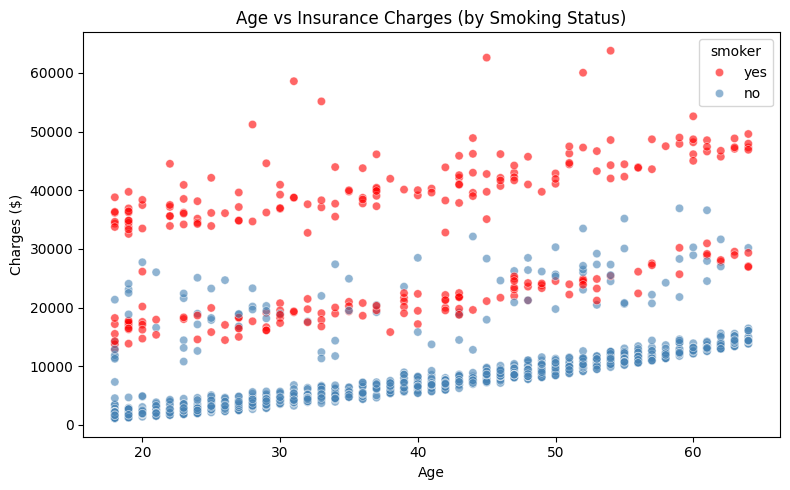

Insight: Both age and smoking increase charges, but smoking has the largest single impact.


In [6]:
# ── Age vs Charges (colored by Smoker) ───────────────────────────────────────
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='age', y='charges', hue='smoker',
                palette={'yes': 'red', 'no': 'steelblue'}, alpha=0.6)
plt.title('Age vs Insurance Charges (by Smoking Status)')
plt.xlabel('Age')
plt.ylabel('Charges ($)')
plt.tight_layout()
plt.show()
print('Insight: Both age and smoking increase charges, but smoking has the largest single impact.')

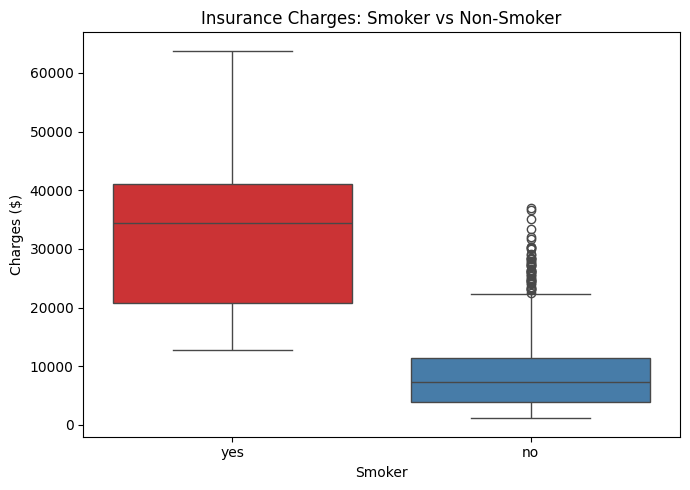

Mean charges — Smoker: $32,050
Mean charges — Non-smoker: $8,434


In [7]:
# ── Smoker vs Non-Smoker charges box plot ─────────────────────────────────────
plt.figure(figsize=(7, 5))
sns.boxplot(data=df, x='smoker', y='charges', palette='Set1')
plt.title('Insurance Charges: Smoker vs Non-Smoker')
plt.xlabel('Smoker')
plt.ylabel('Charges ($)')
plt.tight_layout()
plt.show()

print(f"Mean charges — Smoker: ${df[df['smoker']=='yes']['charges'].mean():,.0f}")
print(f"Mean charges — Non-smoker: ${df[df['smoker']=='no']['charges'].mean():,.0f}")

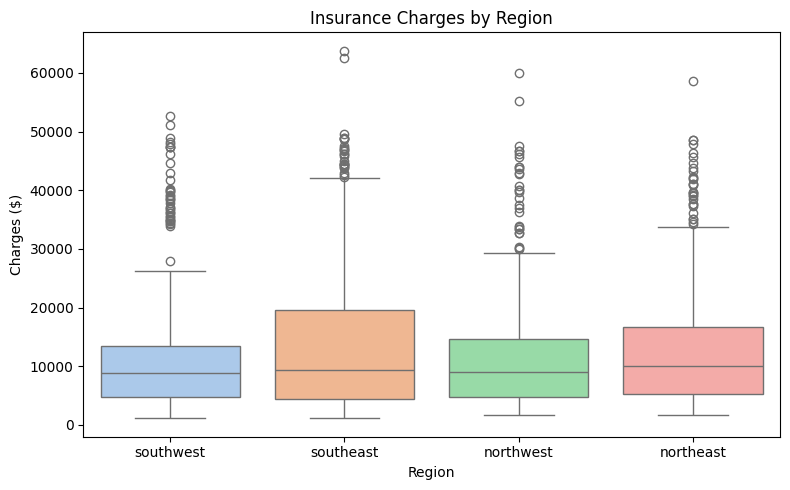

In [8]:
# ── Region vs Charges ─────────────────────────────────────────────────────────
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='region', y='charges', palette='pastel')
plt.title('Insurance Charges by Region')
plt.xlabel('Region')
plt.ylabel('Charges ($)')
plt.tight_layout()
plt.show()

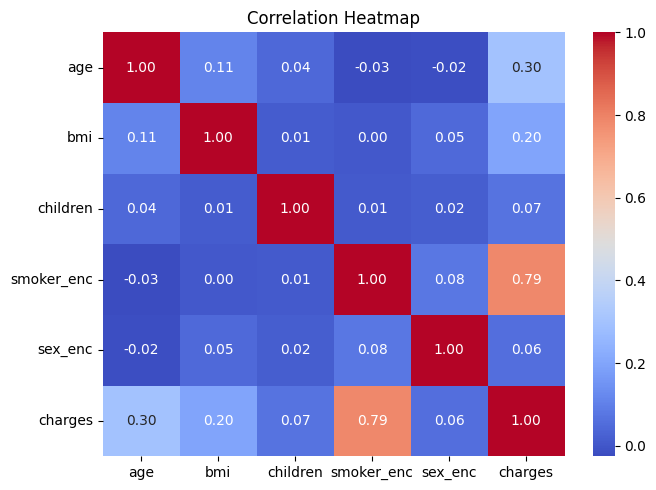

Insight: Smoker status has the strongest correlation with charges (r≈0.79).


In [9]:
# ── Correlation heatmap ──────────────────────────────────────────────────────
df_enc = df.copy()
df_enc['smoker_enc'] = (df_enc['smoker'] == 'yes').astype(int)
df_enc['sex_enc']    = (df_enc['sex'] == 'male').astype(int)
corr_cols = ['age', 'bmi', 'children', 'smoker_enc', 'sex_enc', 'charges']

plt.figure(figsize=(7, 5))
sns.heatmap(df_enc[corr_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()
print('Insight: Smoker status has the strongest correlation with charges (r≈0.79).')

## 3. Data Preparation & Model Training

In [10]:
# ── Encode categorical variables ─────────────────────────────────────────────
df_model = df.copy()
le = LabelEncoder()
for col in ['sex', 'smoker']:
    df_model[col] = le.fit_transform(df_model[col])
df_model = pd.get_dummies(df_model, columns=['region'], drop_first=True)

X = df_model.drop(columns='charges')
y = df_model['charges']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)
print(f'Train: {X_train.shape[0]} | Test: {X_test.shape[0]}')
print('Features:', X.columns.tolist())

Train: 1070 | Test: 268
Features: ['age', 'sex', 'bmi', 'children', 'smoker', 'region_northwest', 'region_southeast', 'region_southwest']


In [11]:
# ── Train models ─────────────────────────────────────────────────────────────
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression':  Ridge(alpha=10),
    'Random Forest':     RandomForestRegressor(n_estimators=100, random_state=42)
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mae  = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2   = r2_score(y_test, y_pred)
    results[name] = {'pred': y_pred, 'mae': mae, 'rmse': rmse, 'r2': r2}
    print(f'{name}: MAE=${mae:,.0f} | RMSE=${rmse:,.0f} | R²={r2:.4f}')

Linear Regression: MAE=$4,181 | RMSE=$5,796 | R²=0.7836
Ridge Regression: MAE=$4,304 | RMSE=$5,856 | R²=0.7791
Random Forest: MAE=$2,551 | RMSE=$4,578 | R²=0.8650


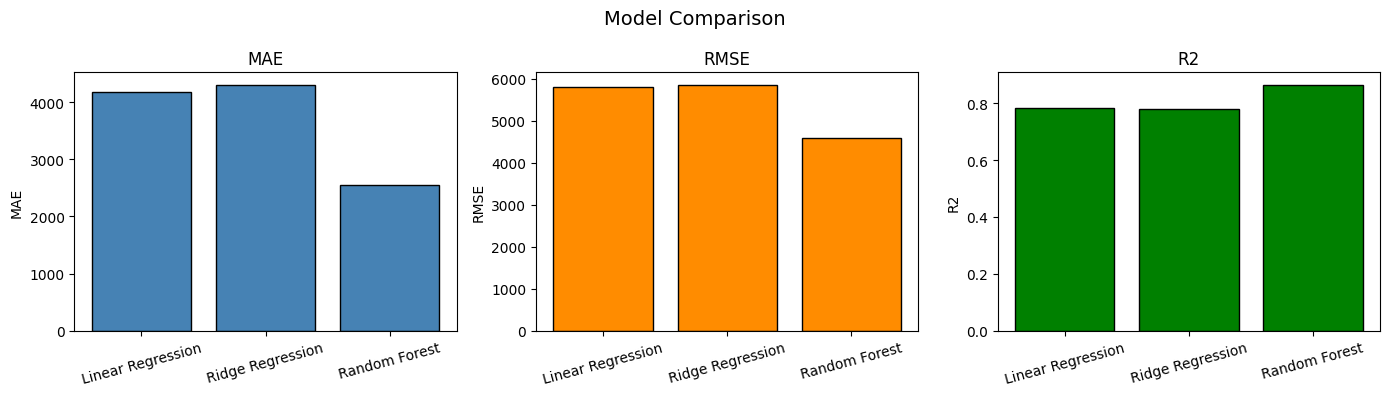

In [12]:
# ── Model Comparison Bar Chart ────────────────────────────────────────────────
metric_df = pd.DataFrame({
    'Model': list(results.keys()),
    'MAE':   [r['mae']  for r in results.values()],
    'RMSE':  [r['rmse'] for r in results.values()],
    'R2':    [r['r2']   for r in results.values()]
})

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col, color in zip(axes, ['MAE', 'RMSE', 'R2'],
                           ['steelblue', 'darkorange', 'green']):
    ax.bar(metric_df['Model'], metric_df[col], color=color, edgecolor='black')
    ax.set_title(col)
    ax.set_ylabel(col)
    ax.tick_params(axis='x', rotation=15)

plt.suptitle('Model Comparison', fontsize=14)
plt.tight_layout()
plt.show()

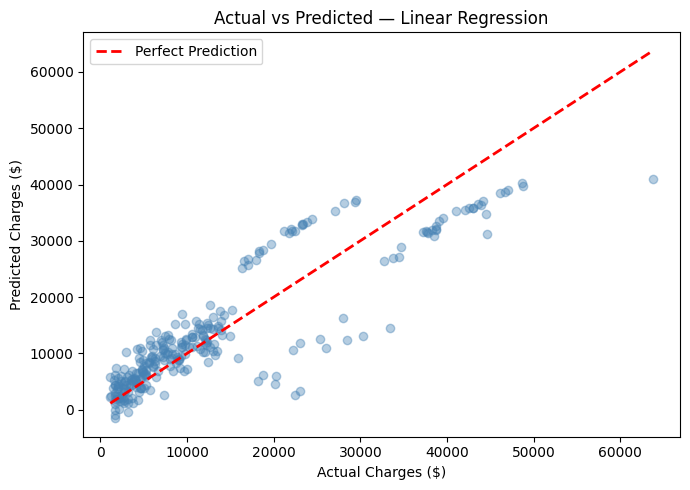

In [13]:
# ── Actual vs Predicted — Linear Regression ──────────────────────────────────
y_pred_lr = results['Linear Regression']['pred']

plt.figure(figsize=(7, 5))
plt.scatter(y_test, y_pred_lr, alpha=0.4, color='steelblue')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual Charges ($)')
plt.ylabel('Predicted Charges ($)')
plt.title('Actual vs Predicted — Linear Regression')
plt.legend()
plt.tight_layout()
plt.show()

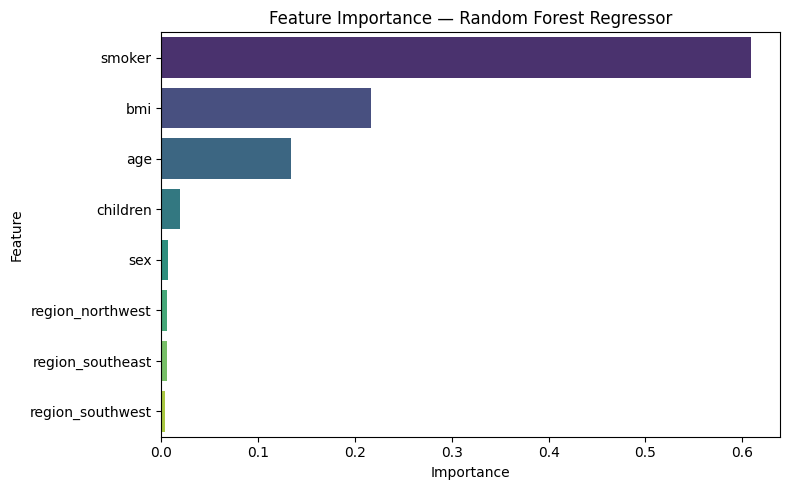

         Feature  Importance
          smoker    0.608618
             bmi    0.216500
             age    0.134203
        children    0.019463
             sex    0.006373
region_northwest    0.005621
region_southeast    0.005284
region_southwest    0.003938


In [14]:
# ── Feature Importance from Random Forest ─────────────────────────────────────
rf = models['Random Forest']
feat_imp = pd.DataFrame({
    'Feature':    X.columns,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(data=feat_imp, x='Importance', y='Feature', palette='viridis')
plt.title('Feature Importance — Random Forest Regressor')
plt.tight_layout()
plt.show()
print(feat_imp.to_string(index=False))

Perfect! Real numbers aa gaye! Yeh raha updated conclusion:

---

## 4. Conclusion

| Model | MAE | RMSE | R² |
|---|---|---|---|
| Linear Regression | 4,181 | 5,796 | 0.7836 |
| Ridge Regression | 4,304 | 5,856 | 0.7791 |
| Random Forest | 2,551 | 4,578 | 0.8650 |

**Random Forest** outperformed both linear models with the lowest MAE and RMSE and highest R² score of 0.865, meaning it explains 86.5% of the variance in insurance charges.

**Key Findings from Feature Importance Analysis:**
- **Smoking status** is by far the most dominant predictor (importance: 0.61) — smokers incur dramatically higher medical charges
- **BMI** is the second most important feature (0.22) — higher BMI directly correlates with increased charges
- **Age** is the third strongest predictor (0.13) — older individuals naturally have higher medical costs
- **Region, sex, and number of children** have minimal impact on charges

**Key Insights:**
- Linear Regression provides a solid interpretable baseline (R²=0.78) but fails to capture non-linear interactions between features
- Random Forest captures complex interactions like smoker × BMI combined effect, which explains its superior performance
- The gap between predicted and actual values in the scatter plot is mostly due to high-charge outliers among smokers

**Business Recommendation:**
Insurance companies should heavily prioritize **smoking status and BMI** when calculating premiums. A non-smoker with normal BMI should receive significantly lower premiums compared to a smoker with high BMI, as these two factors together account for nearly 83% of feature importance.